In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [2]:
models = ['pcv2-l24-d0768', 'pcv2-l48-d1024', 'pcv2-l48-d1536']
contexts = ['512', '1k', '2k', '4k', '8k']

## For conserved sites

In [3]:
conserved = pd.read_csv(f'../../../results/Poaceae_CDS_PhyloP/512/conserved_512_downsampled.tsv.gz', sep='\t')
REF = conserved['Seq'].str[255]
for ctx in contexts:
    for model in models:
        print(f"Processing context window {ctx} of {model}......")
        logitPath = f'../../../results/Poaceae_CDS_PhyloP/{ctx}/conserved_{ctx}_downsampled_{model}_logits_batchSize_32.tsv.gz'
        logits = pd.read_csv(logitPath, header=None, sep='\t')
        logits.columns = ['A', 'C', 'G', 'T']
        scores = conserved.apply(lambda row: logits.loc[row.name, REF.loc[row.name]],axis=1)
        prefix = f'{ctx}_{model}'
        conserved[prefix] = scores

Processing context window 512 of pcv2-l24-d0768......
Processing context window 512 of pcv2-l48-d1024......
Processing context window 512 of pcv2-l48-d1536......
Processing context window 1k of pcv2-l24-d0768......
Processing context window 1k of pcv2-l48-d1024......
Processing context window 1k of pcv2-l48-d1536......
Processing context window 2k of pcv2-l24-d0768......
Processing context window 2k of pcv2-l48-d1024......
Processing context window 2k of pcv2-l48-d1536......
Processing context window 4k of pcv2-l24-d0768......
Processing context window 4k of pcv2-l48-d1024......
Processing context window 4k of pcv2-l48-d1536......
Processing context window 8k of pcv2-l24-d0768......
Processing context window 8k of pcv2-l48-d1024......
Processing context window 8k of pcv2-l48-d1536......


## For PlantCAD1

In [4]:
logitPath = f'../../../results/Poaceae_CDS_PhyloP/512/conserved_512_downsampled_pcv1_logits.tsv.gz'
logits = pd.read_csv(logitPath, header=None, sep='\t')
logits.columns = ['A', 'C', 'G', 'T']
scores = conserved.apply(lambda row: logits.loc[row.name, REF.loc[row.name]],axis=1)
prefix = f'pcv1'
conserved[prefix] = scores

## For GPN

In [5]:
logitPath = f'../../../results/Poaceae_CDS_PhyloP/8k/conserved_8k_downsampled_gpn_logits.tsv'
logits = pd.read_csv(logitPath, header=None, sep='\t')
logits.columns = ['A', 'C', 'G', 'T']
scores = conserved.apply(lambda row: logits.loc[row.name, REF.loc[row.name]],axis=1)
prefix = f'gpn'
conserved[prefix] = scores

## For PDLLMs

In [6]:
logitPath = f'../../../results/Poaceae_CDS_PhyloP/8k/conserved_8k_downsampled_pdllm_logits.tsv'
logits = pd.read_csv(logitPath, header=None, sep='\t')
logits.columns = ['A', 'C', 'G', 'T']
scores = conserved.apply(lambda row: logits.loc[row.name, REF.loc[row.name]],axis=1)
prefix = f'pdllm'
conserved[prefix] = scores

## For evo2

In [7]:
logitPath = f'../../../results/Poaceae_CDS_PhyloP/8k/conserved_8k_downsampled_evo2_logits_new.tsv'
logits = pd.read_csv(logitPath, header=None, sep='\t')
logits.columns = ['A', 'C', 'G', 'T']
scores = conserved.apply(lambda row: logits.loc[row.name, REF.loc[row.name]],axis=1)
prefix = f'evo2'
conserved[prefix] = scores

In [8]:
conserved.head()

,OG,pos,phyloP,start,end,Seq,512_pcv2-l24-d0768,512_pcv2-l48-d1024,512_pcv2-l48-d1536,1k_pcv2-l24-d0768,...,4k_pcv2-l24-d0768,4k_pcv2-l48-d1024,4k_pcv2-l48-d1536,8k_pcv2-l24-d0768,8k_pcv2-l48-d1024,8k_pcv2-l48-d1536,pcv1,gpn,pdllm,evo2
0,OG0000062,356,7.816,1261,9452,GAGGAGTGAAGAAGCCTCACCGATACCGCCCTGGGACTGTTGCCCT...,0.995544,0.999025,0.998209,0.999283,...,0.999340,0.999197,0.999231,0.999395,0.999161,0.999095,0.999656,0.997746,0.137032,1.000000
1,OG0000098,13,9.912,918,9109,CGCTAACATTTCCACCACGTCAGCGATCCAGTCCCAAACACATCAC...,0.965639,0.996440,0.993527,0.988562,...,0.987678,0.996894,0.996630,0.987561,0.996727,0.996312,0.984457,0.915795,0.283253,0.699219
2,OG0000098,83,6.107,988,9179,AACGCATCACAACCATCCACGTCACCGATCCGCGGCATTGCTTCCT...,0.995304,0.991605,0.992949,0.997283,...,0.997024,0.989687,0.992361,0.996630,0.990081,0.991732,0.995171,0.978378,0.792424,0.992188
3,OG0000098,125,7.816,1030,9221,TCCTTCGCCAATCATCGCTCACCCCTCCCCCTCTATAAAGAAACAC...,0.773774,0.954288,0.731490,0.904407,...,0.890690,0.959021,0.666604,0.894712,0.959463,0.698114,0.814271,0.258475,0.223828,0.613281
4,OG0000098,228,9.912,1133,9324,CCAAACGTTTCGGAGCAGCCAAGAAGCCATGGCGCCCAAGGCAGAG...,0.991752,0.986512,0.988258,0.996352,...,0.996624,0.993946,0.993945,0.996476,0.992511,0.995742,0.994071,0.956687,0.940393,0.976562


## Merge neutral files

In [9]:
neutral = pd.read_csv(f'../../../results/Poaceae_CDS_PhyloP/512/neutral_512_downsampled.tsv.gz', sep='\t')
REF = neutral['Seq'].str[255]
for ctx in contexts:
    for model in models:
        print(f"Processing context window {ctx} of {model}......")
        logitPath = f'../../../results/Poaceae_CDS_PhyloP/{ctx}/neutral_{ctx}_downsampled_{model}_logits_batchSize_32.tsv.gz'
        logits = pd.read_csv(logitPath, header=None, sep='\t')
        logits.columns = ['A', 'C', 'G', 'T']
        scores = neutral.apply(lambda row: logits.loc[row.name, REF.loc[row.name]],axis=1)
        prefix = f'{ctx}_{model}'
        neutral[prefix] = scores

Processing context window 512 of pcv2-l24-d0768......
Processing context window 512 of pcv2-l48-d1024......
Processing context window 512 of pcv2-l48-d1536......
Processing context window 1k of pcv2-l24-d0768......
Processing context window 1k of pcv2-l48-d1024......
Processing context window 1k of pcv2-l48-d1536......
Processing context window 2k of pcv2-l24-d0768......
Processing context window 2k of pcv2-l48-d1024......
Processing context window 2k of pcv2-l48-d1536......
Processing context window 4k of pcv2-l24-d0768......
Processing context window 4k of pcv2-l48-d1024......
Processing context window 4k of pcv2-l48-d1536......
Processing context window 8k of pcv2-l24-d0768......
Processing context window 8k of pcv2-l48-d1024......
Processing context window 8k of pcv2-l48-d1536......


## For PlantCAD1

In [10]:
logitPath = f'../../../results/Poaceae_CDS_PhyloP/512/neutral_512_downsampled_pcv1_logits.tsv.gz'
logits = pd.read_csv(logitPath, header=None, sep='\t')
logits.columns = ['A', 'C', 'G', 'T']
scores = neutral.apply(lambda row: logits.loc[row.name, REF.loc[row.name]],axis=1)
prefix = f'pcv1'
neutral[prefix] = scores

## GPN

In [11]:
logitPath = f'../../../results/Poaceae_CDS_PhyloP/8k/neutral_8k_downsampled_gpn_logits.tsv'
logits = pd.read_csv(logitPath, header=None, sep='\t')
logits.columns = ['A', 'C', 'G', 'T']
scores = neutral.apply(lambda row: logits.loc[row.name, REF.loc[row.name]],axis=1)
prefix = f'gpn'
neutral[prefix] = scores

## For PDLLMs

In [12]:
logitPath = f'../../../results/Poaceae_CDS_PhyloP/8k/neutral_8k_downsampled_pdllm_logits.tsv'
logits = pd.read_csv(logitPath, header=None, sep='\t')
logits.columns = ['A', 'C', 'G', 'T']
scores = neutral.apply(lambda row: logits.loc[row.name, REF.loc[row.name]],axis=1)
prefix = f'pdllm'
neutral[prefix] = scores

## For Evo2

In [13]:
logitPath = f'../../../results/Poaceae_CDS_PhyloP/8k/neutral_8k_downsampled_evo2_logits_new.tsv'
logits = pd.read_csv(logitPath, header=None, sep='\t')
logits.columns = ['A', 'C', 'G', 'T']
scores = neutral.apply(lambda row: logits.loc[row.name, REF.loc[row.name]],axis=1)
prefix = f'evo2'
neutral[prefix] = scores

In [14]:
neutral.head()

,OG,pos,phyloP,start,end,Seq,512_pcv2-l24-d0768,512_pcv2-l48-d1024,512_pcv2-l48-d1536,1k_pcv2-l24-d0768,...,4k_pcv2-l24-d0768,4k_pcv2-l48-d1024,4k_pcv2-l48-d1536,8k_pcv2-l24-d0768,8k_pcv2-l48-d1024,8k_pcv2-l48-d1536,pcv1,gpn,pdllm,evo2
0,OG0000098,466,-0.156,1371,9562,AAGATCTACATCTTCAAGGTGCTGAAGCAGGTGCACCCTGACATCG...,0.971596,0.996581,0.994158,0.995360,...,0.995837,0.971151,0.987592,0.995194,0.971732,0.984611,0.994251,0.222341,0.191694,0.710938
1,OG0000106,89,0.883,994,9185,ACTTAATCTTAACAAAAACTACTTAATTGTGTACACTAACCATCAA...,0.047195,0.076743,0.043235,0.020041,...,0.019730,0.044508,0.067714,0.019442,0.039195,0.058484,0.013384,0.172337,0.198031,0.035400
2,OG0000106,166,0.813,1071,9262,CCCTAACACAATCTCAAGCCATCACAAGCACTTACTGGTTAGGAGC...,0.873370,0.802612,0.667562,0.816809,...,0.807266,0.899496,0.741385,0.788674,0.850498,0.735380,0.724770,0.699334,0.260499,0.734375
3,OG0000106,261,-1.414,1166,9357,ATCAAAGGTCTCGGTCGCCCTCTTCCTCGCCGTCAACCTCGTCGTG...,0.775061,0.795682,0.192674,0.759222,...,0.776101,0.865687,0.372606,0.785581,0.800396,0.348589,0.680613,0.678111,0.643906,0.789062
4,OG0000124,15,-1.234,920,9111,CCACGGATCGTTCCCCTCCTCGCGCTCTTCCCAGCCACGTCACCGA...,0.076689,0.076038,0.117795,0.041602,...,0.073958,0.061898,0.284527,0.086820,0.073870,0.135184,0.149967,0.055801,0.206220,0.069824


In [15]:
conserved['label'] = 1
neutral['label'] = 0

combined_df = pd.concat([conserved, neutral], ignore_index=True)
y_true = combined_df['label']

In [16]:
models = combined_df.columns[6:].tolist()[:-1]
models

['512_pcv2-l24-d0768',
 '512_pcv2-l48-d1024',
 '512_pcv2-l48-d1536',
 '1k_pcv2-l24-d0768',
 '1k_pcv2-l48-d1024',
 '1k_pcv2-l48-d1536',
 '2k_pcv2-l24-d0768',
 '2k_pcv2-l48-d1024',
 '2k_pcv2-l48-d1536',
 '4k_pcv2-l24-d0768',
 '4k_pcv2-l48-d1024',
 '4k_pcv2-l48-d1536',
 '8k_pcv2-l24-d0768',
 '8k_pcv2-l48-d1024',
 '8k_pcv2-l48-d1536',
 'pcv1',
 'gpn',
 'pdllm',
 'evo2']

In [17]:
results = []

for mdl in models:
    y_scores = combined_df[mdl]
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    if mdl == 'evo2':
        context = 8192
    elif mdl == 'pcv1' or mdl == 'gpn' or mdl == 'pdllm':
        context = 512
    else:
        context = mdl.split('_')[0]
        mdl = "_".join(mdl.split("_")[1:])
    results.append({'model': mdl, 'context': context, 'roc_auc': roc_auc})
results_df = pd.DataFrame(results)

In [18]:
results_df

,model,context,roc_auc
0,pcv2-l24-d0768,512,0.627571
1,pcv2-l48-d1024,512,0.668908
2,pcv2-l48-d1536,512,0.683297
3,pcv2-l24-d0768,1k,0.643690
4,pcv2-l48-d1024,1k,0.687693
5,pcv2-l48-d1536,1k,0.706721
6,pcv2-l24-d0768,2k,0.647592
7,pcv2-l48-d1024,2k,0.690174
8,pcv2-l48-d1536,2k,0.715326
9,pcv2-l24-d0768,4k,0.647540


In [19]:
results_df.to_csv('performance_compairson.tsv', sep='\t', index=False)

In [20]:
subsets_df = results_df[12:]
model_order = ['pcv1', 'pcv2-l24-d0768',  'pcv2-l48-d1024', 'pcv2-l48-d1536', 'evo2', 'gpn', 'pdllm']
subsets_df = subsets_df.set_index('model').reindex(model_order).reset_index()
subsets_df

,model,context,roc_auc
0,pcv1,512,0.726310
1,pcv2-l24-d0768,8k,0.646234
2,pcv2-l48-d1024,8k,0.686926
3,pcv2-l48-d1536,8k,0.712541
4,evo2,8192,0.821577
5,gpn,512,0.606353
6,pdllm,512,0.502980


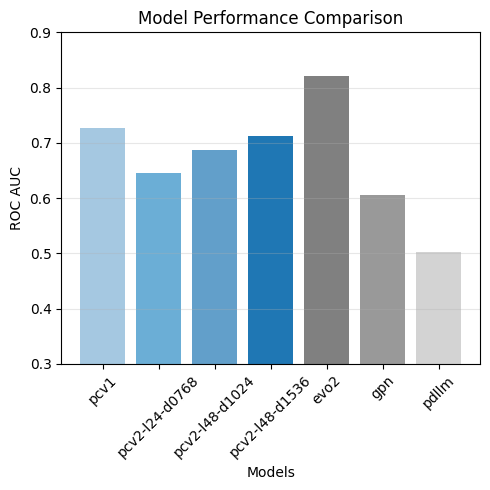

In [21]:
plt.figure(figsize=(5, 5))
colors = ['#1f77b466', '#6baed6', '#1f77b4b3', '#1f77b4ff', '#808080', '#999999', '#d3d3d3']

bars = plt.bar(subsets_df['model'], subsets_df['roc_auc'], color=colors)

plt.xlabel('Models')
plt.ylabel('ROC AUC')
plt.title('Model Performance Comparison')
plt.xticks(rotation=45)
plt.ylim(0.3, 0.9)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('performance_compairson_8k.pdf', format = 'pdf', bbox_inches = 'tight')
plt.show()